In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [77]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Número de registros:", X.shape[0])
print("Número de variables:", X.shape[1])

print("\nClases:")
print(data.target_names)

Número de registros: 569
Número de variables: 30

Clases:
['malignant' 'benign']


In [78]:
df = pd.DataFrame(X, columns=data.feature_names)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [79]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (455, 30)
Prueba: (114, 30)


In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [82]:
modelo = LogisticRegression(max_iter=10000)

modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [83]:
y_pred = modelo.predict(X_test)

y_prob = modelo.predict_proba(X_test)[:,1]

In [84]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  2]
 [ 1 70]]


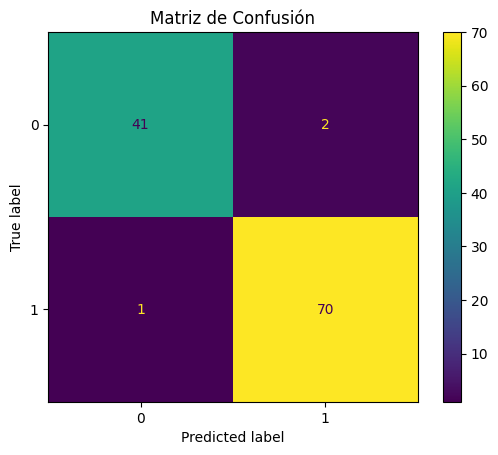

In [85]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Matriz de Confusión")
plt.show()

In [86]:
precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("Precision =", precision)
print("Recall =", recall)
print("F1 Score =", f1)
print("AUC ROC =", auc)

Precision = 0.9722222222222222
Recall = 0.9859154929577465
F1 Score = 0.9790209790209791
AUC ROC = 0.99737962659679


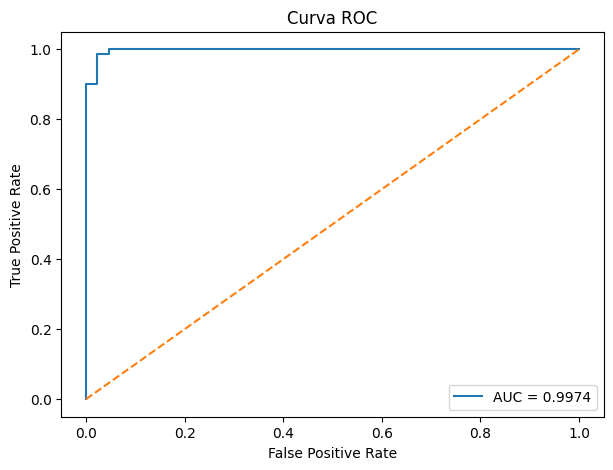

In [87]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Curva ROC"
)

plt.legend()

plt.show()

In [88]:
scores5 = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores5)

print(
    "Promedio K=5:",
    scores5.mean()
)

[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Promedio K=5: 0.9507995652848935


In [89]:
scores10 = cross_val_score(
    modelo,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print(scores10)

print(
    "Promedio K=10:",
    scores10.mean()
)

[0.98245614 0.9122807  0.92982456 0.94736842 0.98245614 0.98245614
 0.92982456 0.94736842 0.96491228 0.96428571]
Promedio K=10: 0.9543233082706767


In [90]:
resultados = pd.DataFrame({
    "Metodo":["K=5","K=10"],
    "Accuracy":[
        scores5.mean(),
        scores10.mean()
    ]
})

resultados

,Metodo,Accuracy
0,K=5,0.950800
1,K=10,0.954323


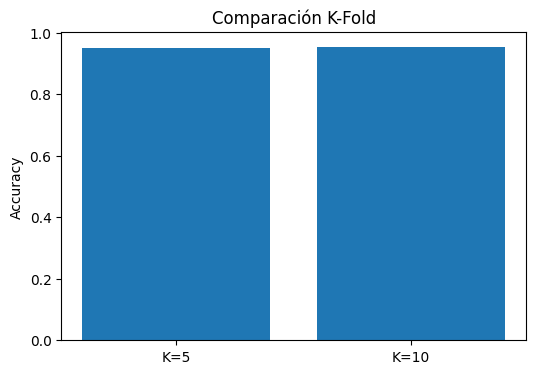

In [91]:
plt.figure(figsize=(6,4))

plt.bar(
    resultados["Metodo"],
    resultados["Accuracy"]
)

plt.title("Comparación K-Fold")

plt.ylabel("Accuracy")

plt.show()

In [92]:
param_grid = {
    "C":[0.01,0.1,1,10,100],
    "solver":[
        "liblinear",
        "lbfgs"
    ]
}

In [93]:
grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(
    X_train,
    y_train
)

print("Mejores parámetros:")
print(grid.best_params_)
print( "\nMejor score:")
print(grid.best_score_)

Mejores parámetros:
{'C': 0.1, 'solver': 'liblinear'}

Mejor score:
0.9780219780219781


In [94]:
param_dist = {
    "C":[0.01,0.1,1,10,100],
    "solver":[
        "liblinear",
        "lbfgs"
    ]
}

In [95]:

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=10000
    ),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    random_state= 19,
    scoring="accuracy"
)

random_search.fit(
    X_train,
    y_train
)

print("Mejores parámetros:")
print(random_search.best_params_)
print("\nMejor score:")
print(random_search.best_score_)

Mejores parámetros:
{'solver': 'lbfgs', 'C': 10}

Mejor score:
0.9758241758241759


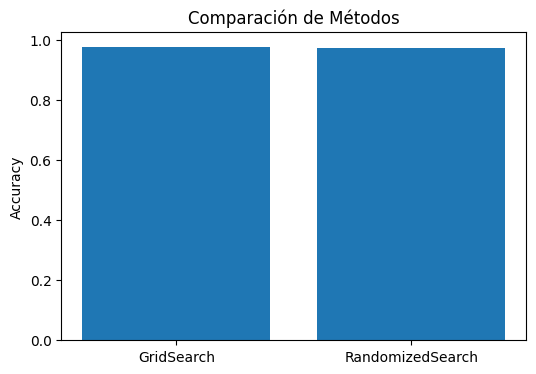

In [96]:
metodos = [
    "GridSearch",
    "RandomizedSearch"
]

scores = [
    grid.best_score_,
    random_search.best_score_
]

plt.figure(figsize=(6,4))

plt.bar(
    metodos,
    scores
)

plt.title(
    "Comparación de Métodos"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [97]:
for umbral in [0.3,0.5,0.7]:

    predicciones = (
        y_prob >= umbral
    ).astype(int)

    precision = precision_score(
        y_test,
        predicciones
    )

    recall = recall_score(
        y_test,
        predicciones
    )

    print("\nUmbral:", umbral)

    print(
        "Precision:",
        precision
    )

    print(
        "Recall:",
        recall
    )


Umbral: 0.3
Precision: 0.9726027397260274
Recall: 1.0

Umbral: 0.5
Precision: 0.9722222222222222
Recall: 0.9859154929577465

Umbral: 0.7
Precision: 0.9852941176470589
Recall: 0.9436619718309859


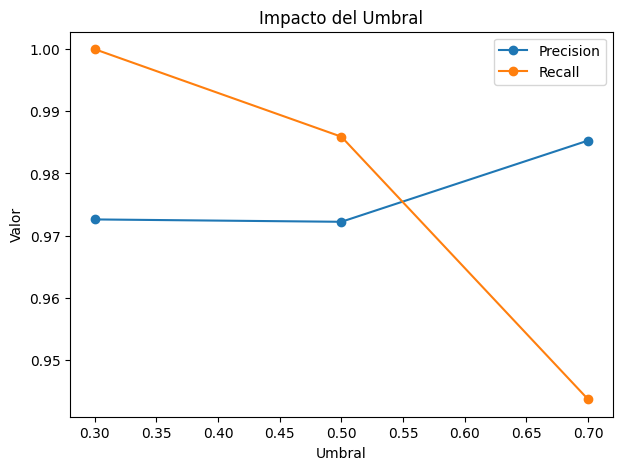

In [98]:
precisiones = []
recalls = []

umbrales = [0.3,0.5,0.7]

for umbral in umbrales:

    predicciones = (
        y_prob >= umbral
    ).astype(int)

    precisiones.append(
        precision_score(
            y_test,
            predicciones
        )
    )

    recalls.append(
        recall_score(
            y_test,
            predicciones
        )
    )

plt.figure(figsize=(7,5))

plt.plot(
    umbrales,
    precisiones,
    marker="o",
    label="Precision"
)

plt.plot(
    umbrales,
    recalls,
    marker="o",
    label="Recall"
)

plt.xlabel("Umbral")

plt.ylabel("Valor")

plt.title(
    "Impacto del Umbral"
)

plt.legend()

plt.show()